# Pipeline CBR + LLM para explicaciones XAI

Notebook reproducible para demostrar el flujo completo:

1. Cargar la base de casos.
2. Definir el perfil del usuario y la imagen clasificada.
3. Recuperar casos similares con CBR.
4. Recomendar el metodo XAI mas adecuado.
5. Construir el prompt para el LLM.
6. Generar o simular una explicacion textual.
7. Registrar feedback del usuario.


## 1. Imports y rutas

In [18]:
from pathlib import Path
import importlib
import json
import sys
import pandas as pd
from IPython.display import Image as DisplayImage, Markdown, display

def find_project_root(start: Path, project_name="TFM-Personalized-XAI") -> Path:
    for candidate in [start, *start.parents]:
        if candidate.name == project_name and (candidate / "evaluacion_online").exists():
            return candidate
        if (candidate / "evaluacion_online").exists() and (candidate / "base_de_casos").exists():
            return candidate
    raise FileNotFoundError(f"No encuentro la raiz del proyecto {project_name}")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import evaluacion_online.llm_cbr_pipeline
importlib.reload(evaluacion_online.llm_cbr_pipeline)

from evaluacion_online.llm_cbr_pipeline import (
    CBRRetriever,
    DEFAULT_CASE_BASE,
    DEFAULT_DESCRIPTIONS,
    DEFAULT_OUTPUT_DIR,
    METHOD_LABEL,
    OPTION_TO_METHOD,
    PipelineResult,
    build_problem_representation,
    build_prompt,
    build_solution_representation,
    generate_with_ollama,
    get_xai_description,
    save_result,
    select_recommended_solution,
)

CASE_BASE = DEFAULT_CASE_BASE
DESCRIPTIONS = DEFAULT_DESCRIPTIONS
OUTPUT_DIR = DEFAULT_OUTPUT_DIR

print("Base de casos:", CASE_BASE)
print("Descripciones XAI:", DESCRIPTIONS)
print("Carpeta de salida:", OUTPUT_DIR)


Base de casos: /Users/haojie/PycharmProjects/TFM-Personalized-XAI/base_de_casos/cbr_case_base_outputs/case_base_double_full.csv
Descripciones XAI: /Users/haojie/PycharmProjects/TFM-Personalized-XAI/generacion_descripcion_XAI/resultados_descripciones_xai/descripciones_por_imagen_xai.csv
Carpeta de salida: /Users/haojie/PycharmProjects/TFM-Personalized-XAI/evaluacion_online/resultados


## 2. Configuracion reproducible

`RUN_OLLAMA = False` hace que el notebook no dependa del modelo local. En ese modo se muestra el prompt y se usa una explicacion simulada para poder probar todo el bucle.

In [19]:
RUN_OLLAMA = False
OLLAMA_MODEL = "qwen2.5vl:32b"
K_NEIGHBORS = 5
SAME_IMAGE_ONLY = False
MIN_SIMILARITY = 0.60

IMAGES_DIR = PROJECT_ROOT / "imagenes"


def project_image_path(folder, file_name):
    return IMAGES_DIR / str(folder) / str(file_name)


def resolve_description_image_path(row):
    raw_path = Path(str(row.get("image_path", "")))
    project_path = project_image_path(raw_path.parent.name, raw_path.name)
    if project_path.exists():
        return project_path
    folder = row.get("folder", "")
    file_name = row.get("file_name", "")
    fallback_path = project_image_path(folder, file_name)
    if fallback_path.exists():
        return fallback_path
    return project_path


IMAGE_METADATA_PATH = PROJECT_ROOT / "base_de_casos/cbr_case_base_outputs/image_metadata_template.csv"
image_map_df = pd.read_csv(IMAGE_METADATA_PATH).rename(
    columns={"model_predicted_class": "class_label"}
)
image_map_df["description_case_id"] = image_map_df["image_id"].astype(int).map(lambda x: f"image{x:02d}")
image_map_df["original_image_path"] = image_map_df["description_case_id"].map(
    lambda case_id: project_image_path("original", f"{case_id}.jpg")
)
image_map_df = image_map_df[
    ["image_id", "image_label", "class_label", "description_case_id", "original_image_path"]
]
IMAGE_ID_TO_DESCRIPTION_CASE = dict(zip(image_map_df["image_id"], image_map_df["description_case_id"]))
IMAGE_ID_TO_LABEL = {
    int(row.image_id): f"{int(row.image_id)} - {row.class_label} ({row.image_label})"
    for row in image_map_df.itertuples(index=False)
}

# Caso de ejemplo: se deriva automaticamente desde image_id.
DEMO_IMAGE_ID = 3
DESCRIPTION_CASE_ID = IMAGE_ID_TO_DESCRIPTION_CASE[DEMO_IMAGE_ID]

print("RUN_OLLAMA:", RUN_OLLAMA)
print("Modelo:", OLLAMA_MODEL)
print("Mapa image_id -> imagen real:")
display(image_map_df)
print("Imagen de ejemplo:", IMAGE_ID_TO_LABEL[DEMO_IMAGE_ID], "->", DESCRIPTION_CASE_ID)


RUN_OLLAMA: False
Modelo: qwen2.5vl:32b
Mapa image_id -> imagen real:


,image_id,image_label,class_label,description_case_id,original_image_path
0,1,img_01,Aguila,image01,/Users/haojie/PycharmProjects/TFM-Personalized...
1,2,img_02,Pato,image02,/Users/haojie/PycharmProjects/TFM-Personalized...
2,3,img_03,Serpiente,image03,/Users/haojie/PycharmProjects/TFM-Personalized...
3,4,img_04,Araña,image04,/Users/haojie/PycharmProjects/TFM-Personalized...
4,5,img_05,Mariposa,image05,/Users/haojie/PycharmProjects/TFM-Personalized...
5,6,img_06,Tigre,image06,/Users/haojie/PycharmProjects/TFM-Personalized...
6,7,img_07,Pajaro,image07,/Users/haojie/PycharmProjects/TFM-Personalized...
7,8,img_08,Mariposa,image08,/Users/haojie/PycharmProjects/TFM-Personalized...
8,9,img_09,Aguila,image09,/Users/haojie/PycharmProjects/TFM-Personalized...
9,10,img_10,Elefante,image10,/Users/haojie/PycharmProjects/TFM-Personalized...


Imagen de ejemplo: 3 - Serpiente (img_03) -> image03


## 3. Perfil del usuario

Esta celda representa el formulario minimo que se le pediria al usuario antes de recuperar casos similares.

In [20]:
query = {
    "image_id": DEMO_IMAGE_ID,
    "age_range": "25-34",
    "education_level": "Master",
    "occupation_raw": "Investigador/a (academico)",
    "ai_knowledge_level": 4,
    "domain_knowledge_level": 3,
    "preferred_response_length": "Media: explicacion breve con algo de detalle",
    "preferred_technical_level": "Intermedio: algunos terminos tecnicos, pero faciles de seguir",
    "preferred_format": "Texto breve + imagen",
    "preferred_explanation_types_raw": (
        "Explicaciones con ejemplos similares, "
        "Explicaciones visuales (zonas destacadas en la imagen)"
    ),
    "main_goals_raw": (
        "Transparencia: entender por que el sistema tomo esa decision, "
        "Confianza: sentir mayor seguridad en la respuesta del sistema"
    ),
    "perceived_error_impact": "Medio: el error podria causar cierta confusion o problema",
}

pd.Series(query).to_frame("valor")


,valor
image_id,3
age_range,25-34
education_level,Master
occupation_raw,Investigador/a (academico)
ai_knowledge_level,4
domain_knowledge_level,3
preferred_response_length,Media: explicacion breve con algo de detalle
preferred_technical_level,"Intermedio: algunos terminos tecnicos, pero fa..."
preferred_format,Texto breve + imagen
preferred_explanation_types_raw,"Explicaciones con ejemplos similares, Explicac..."


## 4. Cargar base de casos y recuperar vecinos

In [21]:
retriever = CBRRetriever(CASE_BASE)
print("Filas en la base:", retriever.df.shape[0])
print("Columnas:", retriever.df.shape[1])

neighbors = retriever.get_neighbors(
    query=query,
    k=K_NEIGHBORS,
    same_image_only=SAME_IMAGE_ONLY,
        min_similarity=MIN_SIMILARITY,
)

neighbor_cols = [
    "case_id",
    "user_id",
    "image_id",
    "selected_option",
    "similarity",
    "mean_helpfulness",
    "satisfaction",
    "confidence",
    "understanding",
]
neighbors[neighbor_cols]


Filas en la base: 297
Columnas: 43


,case_id,user_id,image_id,selected_option,similarity,mean_helpfulness,satisfaction,confidence,understanding
0,C0047,U005,3,Opción E,0.991242,4.666667,5,5,4
1,C0069,U007,3,Opción E,0.990410,3.666667,3,4,4
2,C0102,U010,3,Opción E,0.982727,4.000000,4,4,4
3,C0267,U025,3,Opción A,0.982387,4.000000,4,4,4
4,C0157,U015,3,Opción A,0.982387,4.333333,4,4,5


## 5. Ranking de soluciones recuperadas

El ranking combina similitud del vecino y utilidad observada en la base de casos.

In [22]:
ranking = retriever.recommend_explanation(neighbors)
ranking

,selected_option,n_neighbors,mean_similarity,mean_utility,total_weighted_vote
0,Opción E,3,0.988127,4.111111,12.188210
1,Opción A,2,0.982387,4.166667,8.186562


In [23]:
recommended_option, recommended_method, recommendation_note = select_recommended_solution(ranking)
neighbor = retriever.best_neighbor_for_option(neighbors, recommended_option)

summary = {
    "opcion_recomendada": recommended_option,
    "metodo_xai": METHOD_LABEL[recommended_method],
    "caso_vecino": neighbor["case_id"],
    "similitud": round(float(neighbor["similarity"]), 3),
    "utilidad_media": neighbor["mean_helpfulness"],
}
pd.Series(summary).to_frame("valor")


,valor
opcion_recomendada,Opción E
metodo_xai,Saliency
caso_vecino,C0047
similitud,0.991
utilidad_media,4.666667


## 6. Imagen escogida

Se muestra la imagen original asociada al caso de descripcion y, debajo, la visualizacion XAI del metodo recomendado por el CBR.

### Imagen original: `image03`

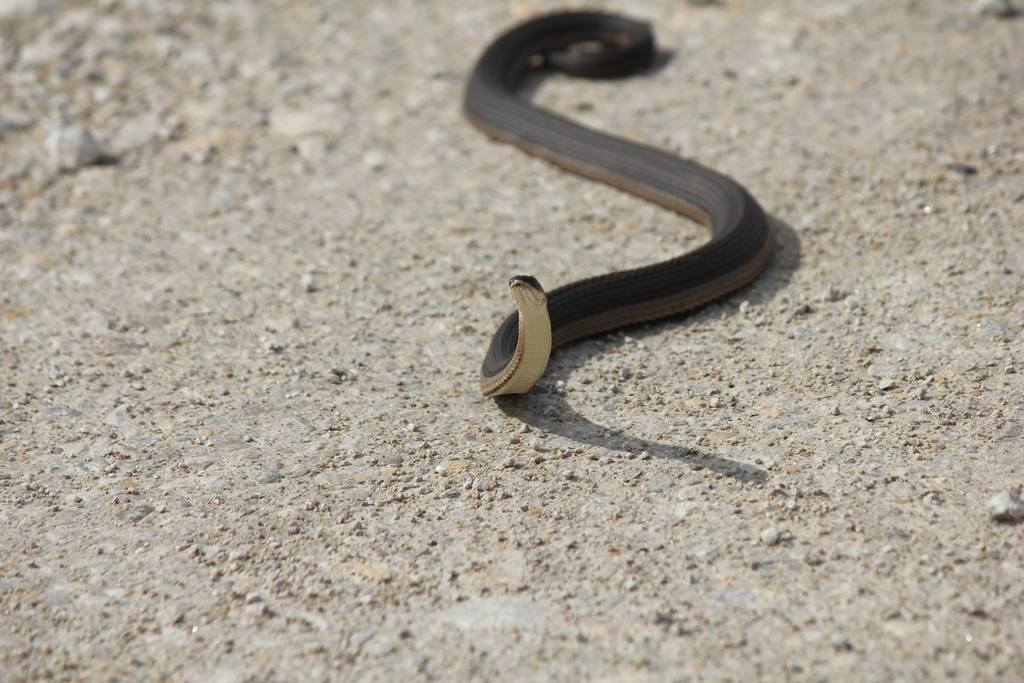

### Visualizacion XAI recomendada: Saliency

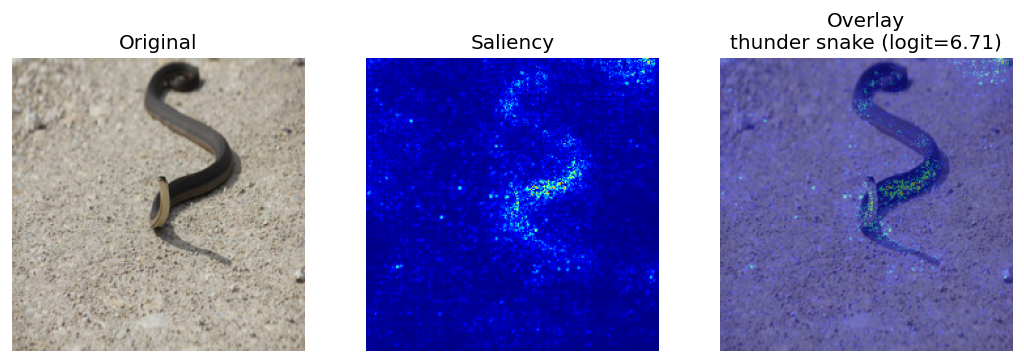

In [24]:
descriptions_df = pd.read_csv(DESCRIPTIONS)
case_descriptions = descriptions_df[
    descriptions_df["case_id"].astype(str) == str(DESCRIPTION_CASE_ID)
]

original_rows = case_descriptions[case_descriptions["method"] == "original"]
xai_rows = case_descriptions[case_descriptions["method"] == recommended_method]

original_path = resolve_description_image_path(original_rows.iloc[0]) if not original_rows.empty else None
xai_path = resolve_description_image_path(xai_rows.iloc[0]) if not xai_rows.empty else None

if original_path and original_path.exists():
    display(Markdown(f"### Imagen original: `{DESCRIPTION_CASE_ID}`"))
    display(DisplayImage(filename=str(original_path), width=260))
else:
    display(Markdown("No se encontro la imagen original para este caso."))

if xai_path and xai_path.exists():
    display(Markdown(f"### Visualizacion XAI recomendada: {METHOD_LABEL[recommended_method]}"))
    display(DisplayImage(filename=str(xai_path), width=320))
else:
    display(Markdown("No se encontro la visualizacion XAI recomendada para este caso."))

## 7. Descripcion XAI disponible

Se recupera la descripcion textual generada previamente para el metodo XAI recomendado.

In [25]:
xai_description = get_xai_description(
    DESCRIPTIONS,
    method=recommended_method,
    description_case_id=DESCRIPTION_CASE_ID,
)

display(Markdown(xai_description if xai_description else "No hay descripcion XAI disponible."))

The base image shows: A snake with a dark, glossy body and a lighter underside coils gracefully on a rough, light-colored gravel surface, casting a subtle shadow.. Method saliency: Saliency Maps highlight the pixels where small changes would most affect the model output; brighter areas indicate greater sensitivity. The generated visualization can be visually described as: This XAI visualization compares an original image of a snake on a sandy surface with its saliency map and an overlay indicating the presence of a "thunder snake" with a logit score of 6.71, highlighting the snake's body in warm, bright regions, suggesting the model's focus on the snake as the primary subject of interest..

## 8. Prompt para el LLM

In [26]:
prompt = build_prompt(
    query=query,
    recommended_option=recommended_option,
    recommended_method=recommended_method,
    neighbor=neighbor,
    xai_description=xai_description,
)

display(Markdown("```text\n" + prompt + "\n```"))

```text
Eres un modulo LLM para explicar una clasificacion de imagen con XAI.
Genera una explicacion personalizada en espanol.

Problema CBR - capa de contenido:
- Imagen original: no indicado
- Descripcion inicial: no indicado
- Dominio de la imagen: no indicado
- Clase predicha / respuesta principal del modelo: no indicado
- Confianza del modelo: no indicado
- Descripcion VQA de apoyo: no indicado

Problema CBR - capa de preferencias del usuario:
- Rol / ocupacion: Investigador/a (academico)
- Nivel educativo: Master
- Conocimiento del dominio: 3/5
- Conocimiento de IA: 4/5

Solucion recuperada por CBR:
- Opcion recomendada: Opción E
- Metodo XAI recomendado: Saliency
- Tipo de opcion en la base: no indicado
- Basado en features: True - Heatmaps, regiones o superpixeles que justifican la prediccion.
- Basado en instancias: True - Ejemplos de casos o imagenes similares recuperados por el CBR.
- Contraejemplos: False - Imagenes o casos claramente distintos para contrastar la decision y evitar sesgos.
- Limitaciones / dudas: True - Incertidumbres detectadas: calidad de evidencia, posible confusion entre clases, falta de evidencia o confianza no disponible.
- K_instancias: 3
- K_contraejemplos: 0
- Longitud final recuperada: media
- Nivel tecnico final recuperado: tecnico
- Estructura final recuperada: lista
- Formato final recuperado: Texto breve + imagen
- Caso vecino usado como referencia: C0047
- Similitud: 0.991
- Solucion elegida por el vecino: Opción E
- Metodo asociado al vecino: Saliency
- Utilidad media del vecino: 4.666666666666667
- Satisfaccion/confianza/comprension del vecino: 5/5/4
- Comentario libre del vecino: no indicado

Descripcion de la imagen y explicacion XAI disponible:
The base image shows: A snake with a dark, glossy body and a lighter underside coils gracefully on a rough, light-colored gravel surface, casting a subtle shadow.. Method saliency: Saliency Maps highlight the pixels where small changes would most affect the model output; brighter areas indicate greater sensitivity. The generated visualization can be visually described as: This XAI visualization compares an original image of a snake on a sandy surface with its saliency map and an overlay indicating the presence of a "thunder snake" with a logit score of 6.71, highlighting the snake's body in warm, bright regions, suggesting the model's focus on the snake as the primary subject of interest..

Contraejemplos reales seleccionados por el CBR:
No se han seleccionado contraejemplos reales.

Instrucciones:
- Ajusta el nivel tecnico al perfil.
- Genera la respuesta siguiendo la solucion CBR: features, instancias, contraejemplos y limitaciones solo cuando esten marcados como True.
- Si hablas de contraejemplos, usa solo los contraejemplos reales listados arriba. No inventes otros.
- Respeta longitud, nivel tecnico y estructura final.
- No inventes detalles visuales que no aparezcan en la descripcion disponible.
- Si falta informacion, dilo con cautela.
- Termina con una frase breve preguntando si la explicacion le convence.

```

## 9. Generar explicacion

Con `RUN_OLLAMA = True`, esta celda llama al modelo local. Con `False`, genera una salida determinista para validar el experimento sin depender del LLM.

In [27]:
def simulated_explanation(method_label, xai_text):
    return (
        f"La explicacion recomendada es {method_label}. "
        "El sistema ha recuperado casos de usuarios con un perfil parecido y, "
        "segun sus valoraciones previas, este tipo de explicacion encaja bien con tus objetivos de transparencia y confianza.\n\n"
        f"En esta imagen, la descripcion XAI disponible indica: {xai_text}\n\n"
        "En resumen, la explicacion ayuda a comprobar que la decision del modelo se apoya en zonas relevantes de la imagen. "
        "Te convence esta explicacion?"
    )

if RUN_OLLAMA:
    explanation = generate_with_ollama(prompt, OLLAMA_MODEL)
else:
    explanation = simulated_explanation(METHOD_LABEL[recommended_method], xai_description)

display(Markdown(explanation))

La explicacion recomendada es Saliency. El sistema ha recuperado casos de usuarios con un perfil parecido y, segun sus valoraciones previas, este tipo de explicacion encaja bien con tus objetivos de transparencia y confianza.

En esta imagen, la descripcion XAI disponible indica: The base image shows: A snake with a dark, glossy body and a lighter underside coils gracefully on a rough, light-colored gravel surface, casting a subtle shadow.. Method saliency: Saliency Maps highlight the pixels where small changes would most affect the model output; brighter areas indicate greater sensitivity. The generated visualization can be visually described as: This XAI visualization compares an original image of a snake on a sandy surface with its saliency map and an overlay indicating the presence of a "thunder snake" with a logit score of 6.71, highlighting the snake's body in warm, bright regions, suggesting the model's focus on the snake as the primary subject of interest..

En resumen, la explicacion ayuda a comprobar que la decision del modelo se apoya en zonas relevantes de la imagen. Te convence esta explicacion?

## 10. Feedback del usuario

Esta celda simula el caso positivo: el usuario queda convencido y puntua la explicacion. Para el experimento real, estos valores se sustituirian por las respuestas del usuario.

In [28]:
user_feedback = {
    "convinced": True,
    "rating": 4,
    "requested_change": None,
}

result = PipelineResult(
    timestamp=pd.Timestamp.now().isoformat(timespec="seconds"),
    query=query,
    recommended_option=recommended_option,
    recommended_method=recommended_method,
    neighbor_case_id=str(neighbor["case_id"]),
    neighbor_similarity=float(neighbor["similarity"]),
    xai_description=xai_description,
    prompt=prompt,
    explanation=explanation,
    problem=build_problem_representation(query),
    solution=build_solution_representation(query, recommended_option, recommended_method),
    convinced=user_feedback["convinced"],
    rating=user_feedback["rating"],
    requested_change=user_feedback["requested_change"],
    iteration=1,
)

log_path = save_result(result, OUTPUT_DIR)
print("Feedback guardado en:", log_path)


Feedback guardado en: /Users/haojie/PycharmProjects/TFM-Personalized-XAI/evaluacion_online/resultados/llm_cbr_feedback_log.jsonl


## 11. Regeneracion si no convence

Ejemplo reproducible del segundo camino del pipeline: el usuario no queda convencido, pide otro formato y el prompt se actualiza.

In [29]:
requested_change = "Quiero una explicacion mas breve, en formato de 3 puntos, y que diga claramente que zona de la imagen mira el modelo."

second_prompt = build_prompt(
    query=query,
    recommended_option=recommended_option,
    recommended_method=recommended_method,
    neighbor=neighbor,
    xai_description=xai_description,
    requested_change=requested_change,
)

if RUN_OLLAMA:
    second_explanation = generate_with_ollama(second_prompt, OLLAMA_MODEL)
else:
    second_explanation = (
        "1. El metodo recomendado sigue siendo " + METHOD_LABEL[recommended_method] + ".\n"
        "2. La explicacion se centra en las regiones resaltadas como mas sensibles para la decision del modelo.\n"
        "3. En este ejemplo, esas zonas ayudan a comprobar si el modelo mira el sujeto principal y no solo el fondo.\n\n"
        "Te convence ahora esta version?"
    )

display(Markdown("### Necesidad indicada por el usuario\n" + requested_change))
display(Markdown("### Nueva explicacion\n" + second_explanation))

### Necesidad indicada por el usuario
Quiero una explicacion mas breve, en formato de 3 puntos, y que diga claramente que zona de la imagen mira el modelo.

### Nueva explicacion
1. El metodo recomendado sigue siendo Saliency.
2. La explicacion se centra en las regiones resaltadas como mas sensibles para la decision del modelo.
3. En este ejemplo, esas zonas ayudan a comprobar si el modelo mira el sujeto principal y no solo el fondo.

Te convence ahora esta version?

## 12. Lectura del log de feedback

In [30]:
if log_path.exists():
    logs = [json.loads(line) for line in log_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    logs_df = pd.DataFrame(logs)
    display(logs_df.tail(5)[[
        "timestamp",
        "recommended_option",
        "recommended_method",
        "neighbor_case_id",
        "neighbor_similarity",
        "convinced",
        "rating",
        "iteration",
    ]])
else:
    print("Todavia no hay log de feedback.")

,timestamp,recommended_option,recommended_method,neighbor_case_id,neighbor_similarity,convinced,rating,iteration
2,2026-06-15T17:04:40,Opción E,saliency,C0047,0.985404,None,NaN,1
3,2026-06-15T17:06:56,Opción B,gradcam,C0155,0.970646,None,NaN,1
4,2026-06-15T17:11:56,Opción B,gradcam,C0155,0.970646,None,NaN,1
5,2026-06-15T17:19:01,Opción E,saliency,C0047,0.991242,True,4.0,1
6,2026-06-15T17:23:23,Opción E,saliency,C0047,0.991242,True,4.0,1


## 13. Experimento interactivo real

Esta seccion permite ejecutar el pipeline como experimento con un usuario real: se recoge el perfil, se muestra la imagen, se genera una explicacion y se repite el bucle de feedback hasta que el usuario queda convencido.

In [31]:
import html
import ipywidgets as widgets
from IPython.display import clear_output

def make_checkbox_group(options, selected=None):
    selected = set(selected or [])
    return [
        widgets.Checkbox(value=option in selected, description=option, indent=False)
        for option in options
    ]
descriptions_df = pd.read_csv(DESCRIPTIONS)
available_image_ids = sorted(retriever.df["image_id"].dropna().astype(int).unique())
image_selector_options = [
    (IMAGE_ID_TO_LABEL.get(image_id, f"Imagen {image_id}"), image_id)
    for image_id in available_image_ids
    if image_id in IMAGE_ID_TO_DESCRIPTION_CASE
]

age_w = widgets.Dropdown(
    description="Edad",
    options=["18-24", "25-34", "35-44", "45-54", "55-64", "65 o mas"],
    value="25-34",
)
education_w = widgets.Dropdown(
    description="Estudios",
    options=["Bachillerato/FP", "Grado", "Master", "Doctorado", "Prefiero no contestar"],
    value="Master",
)
occupation_options = [
    "Estudiante",
    "Investigador/a (academico)",
    "Docente / profesor/a",
    "Profesional del sector tecnologico / IA / datos",
    "Profesional de otro sector",
    "Desempleado/a / en busqueda",
    "Prefiero no contestar",
]
occupation_checks = make_checkbox_group(
    occupation_options,
    selected=["Investigador/a (academico)"],
)
occupation_box = widgets.VBox(occupation_checks)
ai_level_w = widgets.IntSlider(description="IA", min=1, max=5, value=4)
domain_level_w = widgets.IntSlider(description="Dominio", min=1, max=5, value=3)


def selected_checkbox_values(checkboxes):
    return [checkbox.description for checkbox in checkboxes if checkbox.value]

CBR_INFERRED_PREFERENCE_FIELDS = [
    "preferred_response_length",
    "preferred_technical_level",
    "preferred_format",
    "preferred_explanation_types_raw",
    "main_goals_raw",
    "perceived_error_impact",
]
image_w = widgets.Dropdown(
    description="Imagen",
    options=image_selector_options,
    value=DEMO_IMAGE_ID if DEMO_IMAGE_ID in available_image_ids else image_selector_options[0][1],
    layout=widgets.Layout(width="650px"),
)
method_selector_options = [("Recomendada por CBR", "auto")] + [
    (METHOD_LABEL[method], method)
    for method in ["anchor", "gradcam", "integrated_gradients", "lime", "saliency"]
]
method_w = widgets.Dropdown(
    description="Explicacion",
    options=method_selector_options,
    value="auto",
    layout=widgets.Layout(width="650px"),
)
use_ollama_w = widgets.Checkbox(description="Usar Ollama", value=RUN_OLLAMA)
generate_button = widgets.Button(description="Generar explicacion", button_style="primary")
preview_title = widgets.HTML()
preview_original_image = widgets.Image(layout=widgets.Layout(width="110px"))
preview_xai_title = widgets.HTML()
preview_xai_image = widgets.Image(layout=widgets.Layout(width="170px"))
preview_box = widgets.HBox([
    widgets.VBox([widgets.HTML("<b>Imagen principal</b>"), preview_original_image]),
    widgets.VBox([preview_xai_title, preview_xai_image]),
])

display(Markdown("### Perfil e imagen"))
display(widgets.VBox([
    widgets.HBox([image_w, use_ollama_w]),
    method_w,
    preview_box,
    widgets.HBox([age_w, education_w]),
    widgets.HTML("<b>Ocupacion</b>"),
    occupation_box,
    widgets.HBox([ai_level_w, domain_level_w]),
    widgets.HTML("<i>Longitud, nivel tecnico, formato, impacto, tipos XAI y objetivos se infieren desde los casos recuperados por CBR.</i>"),
    generate_button,
]))

result_box = widgets.VBox()
feedback_box = widgets.VBox()
display(result_box, feedback_box)

interactive_state = {"result": None, "neighbor": None, "iteration": 0, "is_generating": False, "session_history": [], "rejected_methods": []}
ALTERNATIVE_POOL_SIZE = len(retriever.df)

def html_title(text, level=3):
    return widgets.HTML(f"<h{level}>{html.escape(str(text))}</h{level}>")

def html_text(text):
    return widgets.HTML(
        "<div style='white-space:pre-wrap; max-width:900px; line-height:1.45'>"
        f"{html.escape(str(text))}"
        "</div>"
    )

def solution_widget(solution):
    if not solution:
        return widgets.HTML("<i>Solucion CBR no disponible.</i>")
    components = solution.get("explanation_components", {})
    final_output = solution.get("final_output", {})
    rows = [
        ("Basado en features", components.get("based_on_features", {}).get("include"), components.get("based_on_features", {}).get("description")),
        ("Basado en instancias", components.get("based_on_instances", {}).get("include"), components.get("based_on_instances", {}).get("description")),
        ("Contraejemplos", components.get("counterexamples", {}).get("include"), components.get("counterexamples", {}).get("description")),
        ("Limitaciones / dudas", components.get("limitations", {}).get("include"), components.get("limitations", {}).get("description")),
    ]
    rows_html = "".join(
        "<tr>"
        f"<td>{html.escape(str(name))}</td>"
        f"<td>{html.escape(str(include))}</td>"
        f"<td>{html.escape(str(description or ''))}</td>"
        "</tr>"
        for name, include, description in rows
    )
    params = (
        f"<p><b>Metodo:</b> {html.escape(str(solution.get('recommended_method')))} · "
        f"<b>K_instancias:</b> {html.escape(str(solution.get('k_instances')))} · "
        #f"<b>K_contraejemplos:</b> {html.escape(str(solution.get('k_counterexamples')))}</p>"
        f"<p><b>Longitud:</b> {html.escape(str(final_output.get('length')))} · "
        f"<b>Nivel tecnico:</b> {html.escape(str(final_output.get('technical_level')))} · "
        f"<b>Estructura:</b> {html.escape(str(final_output.get('structure')))}</p>"
    )
    return widgets.HTML(
        "<div style='max-width:980px'>"
        + params
        + "<table style='border-collapse:collapse'>"
        + "<thead><tr><th>Componente</th><th>Incluir</th><th>Descripcion</th></tr></thead>"
        + f"<tbody>{rows_html}</tbody></table></div>"
    )

def dataframe_widget(df):
    return widgets.HTML(
        df.to_html(index=False, border=0, classes="dataframe", justify="left")
    )

def image_widget(path, width="220px"):
    image_path = Path(path)
    fmt = image_path.suffix.lower().lstrip(".").replace("jpg", "jpeg")
    return widgets.Image(
        value=image_path.read_bytes(),
        format=fmt,
        layout=widgets.Layout(width=width),
    )

def build_interactive_query():
    return {
        "image_id": image_w.value,
        "age_range": age_w.value,
        "education_level": education_w.value,
        "occupation_raw": ", ".join(selected_checkbox_values(occupation_checks)),
        "ai_knowledge_level": ai_level_w.value,
        "domain_knowledge_level": domain_level_w.value,
    }


def complete_query_with_recovered_preferences(query, neighbor):
    completed_query = dict(query)
    for field in CBR_INFERRED_PREFERENCE_FIELDS:
        value = neighbor.get(field, None)
        if pd.notna(value):
            completed_query[field] = value
    return completed_query

def resolve_image_path(row):
    return resolve_description_image_path(row)


def get_description_row(description_case_id, method):
    case_rows = descriptions_df[descriptions_df["case_id"].astype(str) == str(description_case_id)]
    method_rows = case_rows[case_rows["method"] == method]
    if method_rows.empty:
        return None
    return method_rows.iloc[0]


def build_original_image_widgets(description_case_id):
    row = get_description_row(description_case_id, "original")
    if row is None:
        return []
    original_path = resolve_image_path(row)
    if not original_path.exists():
        return []
    return [
        widgets.HTML("<b>Imagen principal original</b>"),
        image_widget(original_path, width="180px"),
    ]


def build_xai_image_widgets(description_case_id, method, title="Visualizacion XAI seleccionada"):
    if method == "none":
        return [widgets.HTML("<i>No se ha seleccionado una explicacion XAI visual.</i>")]
    row = get_description_row(description_case_id, method)
    if row is None:
        return []
    xai_path = resolve_image_path(row)
    if not xai_path.exists():
        return []
    return [
        widgets.HTML(f"<b>{html.escape(title)}: {html.escape(METHOD_LABEL.get(method, method))}</b>"),
        image_widget(xai_path, width="220px"),
    ]


def build_case_gallery(cases_df, max_items=5, include_xai=True, empty_message="No se pudieron cargar imagenes."):
    cards = []
    for _, case in cases_df.head(max_items).iterrows():
        image_id = case.get("image_id")
        if pd.isna(image_id):
            continue
        image_id = int(image_id)
        description_case_id = IMAGE_ID_TO_DESCRIPTION_CASE.get(image_id)
        if description_case_id is None:
            continue
        method = OPTION_TO_METHOD.get(str(case.get("selected_option")), "none")
        original_widgets = build_original_image_widgets(description_case_id)
        xai_widgets = build_xai_image_widgets(description_case_id, method, title="XAI del caso")
        similarity = case.get("similarity", 0)
        try:
            similarity_text = f"{float(similarity):.3f}"
        except Exception:
            similarity_text = str(similarity)
        card_children = [
            widgets.HTML(
                "<div style='font-size:12px; line-height:1.35'>"
                f"<b>{html.escape(str(case.get('case_id', '')))}</b><br>"
                f"usuario: {html.escape(str(case.get('user_id', '')))}<br>"
                f"image_id: {html.escape(str(image_id))}<br>"
                f"clase: {html.escape(str(case.get('model_predicted_class', '')))}<br>"
                f"opcion: {html.escape(str(case.get('selected_option', '')))}<br>"
                f"sim: {html.escape(similarity_text)}"
                "</div>"
            )
        ]
        if original_widgets:
            card_children.append(original_widgets[-1])
        if include_xai and len(xai_widgets) > 1:
            card_children.append(widgets.HTML(f"<span style='font-size:12px'>{html.escape(METHOD_LABEL.get(method, method))}</span>"))
            card_children.append(xai_widgets[-1])
        cards.append(widgets.VBox(
            card_children,
            layout=widgets.Layout(
                width="180px",
                border="1px solid #ddd",
                padding="6px",
                margin="0 8px 8px 0",
            ),
        ))
    if not cards:
        return widgets.HTML(f"<i>{html.escape(empty_message)}</i>")
    return widgets.HBox(cards, layout=widgets.Layout(flex_flow="row wrap"))


def build_recovered_images_gallery(neighbors, max_items=5):
    return build_case_gallery(
        neighbors,
        max_items=max_items,
        include_xai=True,
        empty_message="No se pudieron cargar imagenes de los vecinos recuperados.",
    )


def selected_manual_method():
    return None if method_w.value == "auto" else method_w.value


def update_selection_preview(change=None):
    selected_image_id = image_w.value
    selected_case_id = IMAGE_ID_TO_DESCRIPTION_CASE[selected_image_id]
    original_row = get_description_row(selected_case_id, "original")
    selected_method = selected_manual_method()
    n_cases = int((retriever.df["image_id"] == selected_image_id).sum())
    method_text = "la recomendada por CBR" if selected_method is None else METHOD_LABEL.get(selected_method, selected_method)
    preview_title.value = (
        f"<b>Previsualizacion seleccionada</b><br>"
        f"<code>image_id</code>: {selected_image_id} · casos en base: {n_cases} · "
        f"imagen: <code>{selected_case_id}</code><br>"
        f"Explicacion a mostrar: <b>{html.escape(str(method_text))}</b>"
    )
    preview_original_image.value = b""
    preview_original_image.format = "png"
    preview_xai_title.value = "<b>Explicacion XAI</b>"
    preview_xai_image.value = b""
    preview_xai_image.format = "png"
    if original_row is not None:
        original_path = resolve_image_path(original_row)
        if original_path.exists():
            preview_original_image.value = original_path.read_bytes()
            preview_original_image.format = original_path.suffix.lower().lstrip(".").replace("jpg", "jpeg")
        else:
            preview_title.value += "<br><span style='color:#b00020'>La ruta de la imagen original no existe.</span>"
    else:
        preview_title.value += "<br><span style='color:#b00020'>No hay imagen original asociada a esta seleccion.</span>"

    if selected_method is None:
        preview_xai_title.value = "<b>Explicacion XAI</b>"
        return
    xai_row = get_description_row(selected_case_id, selected_method)
    if xai_row is None:
        preview_xai_title.value = "<b>Explicacion XAI</b><br><span style='color:#b00020'>No existe visualizacion para este metodo.</span>"
        return
    xai_path = resolve_image_path(xai_row)
    if xai_path.exists():
        preview_xai_title.value = f"<b>{html.escape(METHOD_LABEL.get(selected_method, selected_method))}</b>"
        preview_xai_image.value = xai_path.read_bytes()
        preview_xai_image.format = xai_path.suffix.lower().lstrip(".").replace("jpg", "jpeg")
    else:
        preview_xai_title.value = "<b>Explicacion XAI</b><br><span style='color:#b00020'>La ruta de la visualizacion no existe.</span>"

image_w.observe(update_selection_preview, names="value")
method_w.observe(update_selection_preview, names="value")
update_selection_preview()

def fallback_explanation(method_label, xai_text):
    return (
        f"La explicacion recomendada es {method_label}. "
        "El CBR ha recuperado usuarios con perfil y preferencias similares, y esa solucion obtuvo una buena utilidad.\n\n"
        f"Descripcion XAI usada como apoyo: {xai_text}\n\n"
        "Te convence esta explicacion?"
    )

def method_to_option(method):
    for option, option_method in OPTION_TO_METHOD.items():
        if option_method == method and "Opción" in option:
            return option
    for option, option_method in OPTION_TO_METHOD.items():
        if option_method == method:
            return option
    return None


def select_next_distinct_solution(ranking, rejected_methods=None, preferred_method=None):
    rejected_methods = set(rejected_methods or [])
    if preferred_method and preferred_method not in rejected_methods:
        preferred_option = method_to_option(preferred_method)
        if preferred_option is not None:
            return preferred_option, preferred_method
    for option in ranking["selected_option"]:
        option_text = str(option)
        method = OPTION_TO_METHOD.get(option_text)
        if method is None:
            continue
        if method not in rejected_methods:
            return option_text, method
    return None, None

def retrieve_neighbors_with_fallback(query_real):
    attempts = [
        (SAME_IMAGE_ONLY, MIN_SIMILARITY, "umbral configurado"),
        (SAME_IMAGE_ONLY, None, "sin umbral minimo"),
        (False, None, "sin umbral y permitiendo otras imagenes"),
    ]
    for same_image_only, min_similarity, label in attempts:
        neighbors = retriever.get_neighbors(
            query_real,
            k=ALTERNATIVE_POOL_SIZE,
            same_image_only=same_image_only,
            min_similarity=min_similarity,
        )
        if not neighbors.empty:
            note = (
                f"Recuperacion usada: {label}. "
                f"same_image_only={same_image_only}, min_similarity={min_similarity}."
            )
            return neighbors, note
    raise RuntimeError("No se encontraron vecinos en la base de casos.")


def retrieve_counterexamples(query_real, k=2):
    candidates = retriever.get_neighbors(
        query_real,
        k=ALTERNATIVE_POOL_SIZE,
        same_image_only=False,
        min_similarity=None,
    ).copy()
    if candidates.empty:
        return candidates
    query_image_id = query_real.get("image_id")
    query_class = str(query_real.get("model_predicted_class", "")).strip().lower()
    candidates = candidates[candidates["image_id"] != query_image_id]
    if query_class and "model_predicted_class" in candidates.columns:
        candidates = candidates[
            candidates["model_predicted_class"].fillna("").astype(str).str.strip().str.lower() != query_class
        ]
    if candidates.empty:
        return candidates
    return candidates.sort_values("similarity", ascending=True).head(k).copy()


def counterexamples_to_records(counterexamples):
    records = []
    for _, row in counterexamples.iterrows():
        record = {
            "case_id": str(row.get("case_id", "")),
            "user_id": str(row.get("user_id", "")),
            "image_id": int(row.get("image_id")) if pd.notna(row.get("image_id")) else None,
            "selected_option": str(row.get("selected_option", "")),
            "model_predicted_class": str(row.get("model_predicted_class", "")),
            "similarity": round(float(row.get("similarity", 0.0)), 3),
            "initial_description": str(row.get("initial_description", "")),
        }
        records.append(record)
    return records


def generate_interactive_explanation(requested_change=None, rejected_methods=None, preferred_method=None):
    query_real = retriever.enrich_query_with_image_metadata(build_interactive_query())
    neighbors_pool_real, retrieval_note = retrieve_neighbors_with_fallback(query_real)
    interactive_state["retrieval_note"] = retrieval_note
    ranking_pool_real = retriever.recommend_explanation(neighbors_pool_real)
    option_real, method_real = select_next_distinct_solution(
        ranking_pool_real,
        rejected_methods=rejected_methods,
        preferred_method=preferred_method,
    )
    if option_real is None or method_real is None:
        return None, neighbors_pool_real.head(K_NEIGHBORS).copy(), ranking_pool_real
    neighbor_real = retriever.best_neighbor_for_option(neighbors_pool_real, option_real)
    query_real = complete_query_with_recovered_preferences(query_real, neighbor_real)
    neighbors_real = neighbors_pool_real.head(K_NEIGHBORS).copy()
    if option_real not in set(neighbors_real["selected_option"].astype(str)):
        alternative_row = neighbors_pool_real[neighbors_pool_real["selected_option"].astype(str) == option_real].head(1)
        neighbors_real = pd.concat([neighbors_real, alternative_row], ignore_index=True).drop_duplicates("case_id")
    ranking_real = ranking_pool_real
    counterexamples_real = retrieve_counterexamples(query_real, k=2)
    counterexample_records = counterexamples_to_records(counterexamples_real)
    interactive_state["counterexamples"] = counterexamples_real
    xai_text_real = get_xai_description(
        DESCRIPTIONS,
        method=method_real,
        description_case_id=IMAGE_ID_TO_DESCRIPTION_CASE[query_real["image_id"]],
    )
    prompt_real = build_prompt(
        query=query_real,
        recommended_option=option_real,
        recommended_method=method_real,
        neighbor=neighbor_real,
        xai_description=xai_text_real,
        counterexamples=counterexample_records,
        requested_change=requested_change,
    )
    problem_real = build_problem_representation(query_real)
    solution_real = build_solution_representation(query_real, option_real, method_real)
    if use_ollama_w.value:
        explanation_real = generate_with_ollama(prompt_real, OLLAMA_MODEL)
    else:
        explanation_real = fallback_explanation(METHOD_LABEL[method_real], xai_text_real)
    interactive_state["iteration"] += 1
    result_real = PipelineResult(
        timestamp=pd.Timestamp.now().isoformat(timespec="seconds"),
        query=query_real,
        recommended_option=option_real,
        recommended_method=method_real,
        neighbor_case_id=str(neighbor_real["case_id"]),
        neighbor_similarity=float(neighbor_real["similarity"]),
        xai_description=xai_text_real,
        prompt=prompt_real,
        explanation=explanation_real,
        problem=problem_real,
        solution=solution_real,
        counterexamples=counterexample_records,
        requested_change=requested_change,
        iteration=interactive_state["iteration"],
    )
    interactive_state["result"] = result_real
    interactive_state["neighbor"] = neighbor_real
    return result_real, neighbors_real, ranking_real

def record_generation(result, neighbors, ranking, requested_change=None):
    neighbor_cols = ["case_id", "user_id", "image_id", "selected_option", "similarity", "mean_helpfulness"]
    interactive_state["session_history"].append({
        "event": "generation",
        "iteration": result.iteration,
        "requested_change": requested_change,
        "result": result.__dict__.copy(),
        "neighbors": neighbors[neighbor_cols].copy(),
        "ranking": ranking.copy(),
    })

def record_feedback(result):
    interactive_state["session_history"].append({
        "event": "feedback",
        "iteration": result.iteration,
        "convinced": result.convinced,
        "rating": result.rating,
        "acceptance": result.acceptance,
        "satisfaction": result.satisfaction,
        "confidence": result.confidence,
        "understanding": result.understanding,
        "requested_change": result.requested_change,
    })

def append_new_explanation(result, neighbors):
    children = list(result_box.children)
    children.extend([
        widgets.HTML(f"<p><b>Metodo alternativo seleccionado:</b> {html.escape(str(METHOD_LABEL.get(result.recommended_method, result.recommended_method)))}</p>"),
        html_title(f"Imagenes recuperadas usadas - iteracion {result.iteration}", level=3),
        build_recovered_images_gallery(neighbors),
        html_title(f"Contraejemplos reales usados - iteracion {result.iteration}", level=3),
        build_case_gallery(pd.DataFrame(result.counterexamples or []), include_xai=False, empty_message="No se seleccionaron contraejemplos reales."),
        html_title(f"Nueva solucion CBR - iteracion {result.iteration}", level=3),
        solution_widget(result.solution),
        html_title(f"Nueva explicacion - iteracion {result.iteration}", level=3),
        html_text(result.explanation),
    ])
    result_box.children = tuple(children)

def render_feedback_controls(message=None, free_feedback_mode=False):
    convinced_w = widgets.ToggleButtons(
        options=[("Si", True), ("No", False)],
        description="Convence?",
        value=True,
    )
    acceptance_w = widgets.IntSlider(description="Aceptacion", min=1, max=5, value=4)
    satisfaction_w = widgets.IntSlider(description="Satisfaccion", min=1, max=5, value=4)
    confidence_w = widgets.IntSlider(description="Confianza", min=1, max=5, value=4)
    understanding_w = widgets.IntSlider(description="Comprension", min=1, max=5, value=4)
    positive_feedback_box = widgets.VBox([
        widgets.HTML("<b>Evalua la explicacion de 1 a 5</b>"),
        acceptance_w,
        satisfaction_w,
        confidence_w,
        understanding_w,
    ])
    needs_w = widgets.Textarea(
        description="Necesito",
        placeholder="Que necesitas saber o en que formato lo quieres?",
        layout=widgets.Layout(width="850px", height="80px"),
    )
    submit_w = widgets.Button(description="Enviar feedback", button_style="success")
    status_w = widgets.HTML("")

    def refresh_visible_fields(change=None):
        if convinced_w.value:
            positive_feedback_box.layout.display = ""
            needs_w.layout.display = "none"
        else:
            positive_feedback_box.layout.display = "none"
            needs_w.layout.display = "" if free_feedback_mode else "none"

    def save_negative_feedback(current, requested_change=None, alternatives_exhausted=False):
        current.convinced = False
        current.rating = None
        current.acceptance = None
        current.satisfaction = None
        current.confidence = None
        current.understanding = None
        current.requested_change = requested_change
        current.alternatives_exhausted = alternatives_exhausted
        record_feedback(current)
        save_result(current, OUTPUT_DIR)

    def on_submit(_):
        current = interactive_state["result"]
        if current is None:
            return

        if convinced_w.value:
            current.convinced = True
            current.acceptance = int(acceptance_w.value)
            current.satisfaction = int(satisfaction_w.value)
            current.confidence = int(confidence_w.value)
            current.understanding = int(understanding_w.value)
            current.rating = int(round((
                current.acceptance + current.satisfaction + current.confidence + current.understanding
            ) / 4))
            current.requested_change = None
            current.alternatives_exhausted = False
            record_feedback(current)
            path = save_result(current, OUTPUT_DIR)
            feedback_box.children = (
                widgets.HTML(f"Feedback guardado en <code>{html.escape(str(path))}</code>. Experimento completado."),
            )
            return

        rejected_methods = interactive_state.setdefault("rejected_methods", [])
        if current.recommended_method not in rejected_methods:
            rejected_methods.append(current.recommended_method)

        if not free_feedback_mode:
            save_negative_feedback(current, requested_change=None, alternatives_exhausted=False)
            status_w.value = "Probando la siguiente solucion XAI recuperada por CBR..."
            new_result, new_neighbors, new_ranking = generate_interactive_explanation(
                requested_change=None,
                rejected_methods=rejected_methods,
            )
            if new_result is None:
                feedback_box.children = (
                    render_feedback_controls(
                        "Se han agotado los metodos XAI alternativos del ranking CBR. Ahora indica que necesitas saber o en que formato lo quieres:",
                        free_feedback_mode=True,
                    ),
                )
                return
            record_generation(new_result, new_neighbors, new_ranking, requested_change=None)
            append_new_explanation(new_result, new_neighbors)
            feedback_box.children = (
                render_feedback_controls(
                    "La respuesta anterior se guardo como no convincente. Evalua la nueva solucion CBR:"
                ),
            )
            return

        requested_change = needs_w.value.strip()
        if not requested_change:
            status_w.value = "<span style='color:#b00020'>Indica que necesitas saber o en que formato lo quieres.</span>"
            return

        save_negative_feedback(current, requested_change=requested_change, alternatives_exhausted=True)
        feedback_box.children = (
            widgets.HTML("Feedback final guardado. Se han agotado los metodos XAI y el experimento queda cerrado."),
        )
        return

    convinced_w.observe(refresh_visible_fields, names="value")
    submit_w.on_click(on_submit)
    refresh_visible_fields()

    items = []
    if message:
        items.append(widgets.HTML(f"<b>{html.escape(message)}</b>"))
    items.extend([convinced_w, positive_feedback_box])
    if free_feedback_mode:
        items.append(needs_w)
    items.extend([submit_w, status_w])
    return widgets.VBox(items)

def on_generate(_):
    if interactive_state.get("is_generating"):
        return
    interactive_state["is_generating"] = True
    generate_button.disabled = True
    try:
        interactive_state["iteration"] = 0
        interactive_state["session_history"] = []
        interactive_state["rejected_methods"] = []
        result_real, neighbors_real, ranking_real = generate_interactive_explanation(
            preferred_method=selected_manual_method(),
        )
        record_generation(result_real, neighbors_real, ranking_real)
        neighbor_cols = ["case_id", "user_id", "image_id", "selected_option", "similarity", "mean_helpfulness"]
        result_children = [html_title("Imagen principal y explicacion XAI mostrada", level=3)]
        description_case_id = IMAGE_ID_TO_DESCRIPTION_CASE[result_real.query["image_id"]]
        result_children.extend(build_original_image_widgets(description_case_id))
        result_children.extend(
            build_xai_image_widgets(
                description_case_id,
                result_real.recommended_method,
                title="Visualizacion XAI mostrada al usuario",
            )
        )
        inferred_preferences = {field: result_real.query.get(field, "") for field in CBR_INFERRED_PREFERENCE_FIELDS}
        result_children.extend([
            widgets.HTML("<p><b>Regla de rechazo:</b> si el usuario indica que no le convence, se prueba el siguiente metodo XAI distinto del ranking CBR.</p>"),
            widgets.HTML(f"<p><b>Nota de recuperacion:</b> {html.escape(str(interactive_state.get('retrieval_note', '')))}</p>"),
            html_title("Preferencias inferidas desde el CBR", level=3),
            dataframe_widget(pd.DataFrame([inferred_preferences])),
            html_title("Imagenes recuperadas usadas - iteracion 1", level=3),
            build_recovered_images_gallery(neighbors_real),
            html_title("Contraejemplos reales usados - iteracion 1", level=3),
            build_case_gallery(pd.DataFrame(result_real.counterexamples or []), include_xai=False, empty_message="No se seleccionaron contraejemplos reales."),
            html_title("Vecinos recuperados visibles", level=3),
            dataframe_widget(neighbors_real[neighbor_cols]),
            html_title("Ranking CBR por metodo/opcion", level=3),
            dataframe_widget(ranking_real),
            html_title("Solucion CBR enviada al LLM", level=3),
            solution_widget(result_real.solution),
            html_title(f"Explicacion generada - iteracion {result_real.iteration}", level=3),
            html_text(result_real.explanation),
        ])
        result_box.children = tuple(result_children)
        feedback_box.children = (render_feedback_controls(),)
    finally:
        generate_button.disabled = False
        interactive_state["is_generating"] = False

# Evita duplicados si la celda se ejecuta varias veces en la misma sesion.
generate_button._click_handlers.callbacks = []
generate_button.on_click(on_generate)


### Perfil e imagen

VBox()

VBox()